# Training Language Classifier

Arabic vs English with **classical NLP only**: `preprocess_language_detection` → character TF-IDF (2–5) → Linear SVM.

Unique source reviews are split **before** derived examples (truncated text, short slices, first two tokens) are assigned to train or test. Related rows share a `source_id` and stay in one partition.

Source grouping does **not** mean zero normalized-text overlap: short derived phrases such as `the` or `فيلم` can still match across different sources. That overlap is measured. Metrics are reported on the full test set and on test rows whose normalized form is absent from training.

Inference uses this saved sklearn Pipeline. There is no Unicode shortcut.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

ROOT = Path("..") if (Path("..") / "data").exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

from src.labels import ARABIC, ENGLISH
from src.language_dataset import build_language_splits
from src.language_model import LanguageClassifier, make_language_pipeline
from src.Preprocessing_pipeline import preprocess_language_detection

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)
LANG_LABELS = [ARABIC, ENGLISH]

## 2. Load Data

English IMDb reviews and Arabic customer reviews. Latin tokens are stripped from Arabic **training** rows so loanwords such as `service` are not labeled Arabic. Mixed-script synthetic rows are added separately.

In [2]:
en = pd.read_csv(ROOT / "data" / "raw" / "english" / "MovieReviewTrainingDatabase.csv")["review"]
ar = pd.read_csv(ROOT / "data" / "raw" / "arabic" / "Final_Data.csv")["review_description"]
en = en.dropna().astype(str)
ar = ar.dropna().astype(str)
en = en[en.str.strip().str.len() > 0].drop_duplicates()
ar = ar[ar.str.strip().str.len() > 0].drop_duplicates()
print("English pool", len(en), "| Arabic pool", len(ar))

English pool 24904 | Arabic pool 39003


## 3. EDA

In [3]:
print("English char length:\n", en.str.len().describe())
print("Arabic char length:\n", ar.str.len().describe())

English char length:
 count   24904.0000
mean     1306.1254
std       988.4471
min        52.0000
25%       695.0000
50%       966.0000
75%      1588.0000
max     13603.0000
Name: review, dtype: float64
Arabic char length:
 count   39003.0000
mean       51.9400
std        68.7915
min         1.0000
25%        15.0000
50%        29.0000
75%        62.0000
max      2481.0000
Name: review_description, dtype: float64


## 4. Split sources, then derive examples

`build_language_splits` groups duplicate *source reviews* that normalize to the same isolated text, splits those source ids, then creates related views. Train/test `source_id` sets must be disjoint. Normalized-text overlap among short slices is expected and is not deleted.

In [4]:
train_df, test_df, overlap_stats = build_language_splits(en, ar)
print("train", train_df["language"].value_counts().to_dict(), "n", len(train_df))
print("test", test_df["language"].value_counts().to_dict(), "n", len(test_df))
print(overlap_stats)
assert overlap_stats["n_source_overlap"] == 0
assert set(train_df["source_id"]).isdisjoint(set(test_df["source_id"]))
train_df[["text", "language", "source_id", "clean_text"]].head(4)

train {'English': 55474, 'Arabic': 55474} n 110948
test {'English': 13837, 'Arabic': 13837} n 27674
{'n_train': 110948, 'n_test': 27674, 'n_source_overlap': 0, 'n_normalized_overlap': 3321, 'n_test_unseen_normalized': 19292, 'n_test_seen_normalized': 8382, 'unseen_class_balance': {'Arabic': 10447, 'English': 8845}, 'test_class_balance': {'English': 13837, 'Arabic': 13837}, 'n_duplicate_sources_merged': 625}


,text,language,source_id,clean_text
0,**** = A masterpiece to be recorded in the books and never forgotten ***1/2...,English,en-norm:a masterpiece to be recorded in the books and never forgotten a clas...,a masterpiece to be recorded in the books and never forgotten a classic in t...
1,"Charlie Kauffman has made weird metaphysical angst popular, but this canad...",English,en-norm:charlie kauffman has made weird metaphysical angst popular but this ...,charlie kauffman has made weird metaphysical angst popular but this canadian...
2,so yes it is quite nostalgic watching the 1st episode because this is the on...,English,en-norm:so yes it is quite nostalgic watching the st episode because this is...,so yes it is quite nostalgic watching the st episode because this is the one...
3,سيئ جداً انصح بعدم تنزيله,Arabic,ar-norm:سيئ جدا انصح بعدم تنزيله,سيئ جدا انصح بعدم تنزيله


## 5. Preprocessing

Same function used at inference: `preprocess_language_detection`. Applied inside `build_language_splits` (`clean_text`).

In [5]:
print("train clean sample:", train_df["clean_text"].iloc[0][:80])
print("preprocess('Hello!') ->", repr(preprocess_language_detection("Hello!")))

train clean sample: a masterpiece to be recorded in the books and never forgotten a classic in time 
preprocess('Hello!') -> 'hello'


## 6–8. Features and model

Character TF-IDF, n-grams 2–5, `max_features=40000`. Fitted on **train only**. Classifier: Linear SVM.

In [6]:
def scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

language_pipeline = make_language_pipeline()
language_pipeline.fit(train_df["clean_text"], train_df["language"])
y_pred = language_pipeline.predict(test_df["clean_text"])
print(language_pipeline)
print(classification_report(test_df["language"], y_pred, labels=LANG_LABELS, digits=4))
print(pd.Series(scores(test_df["language"], y_pred), name="test"))

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char', max_features=40000,
                                 ngram_range=(2, 5))),
                ('clf', LinearSVC(max_iter=2000))])
              precision    recall  f1-score   support

      Arabic     0.9994    0.9999    0.9996     13837
     English     0.9999    0.9994    0.9996     13837

    accuracy                         0.9996     27674
   macro avg     0.9996    0.9996    0.9996     27674
weighted avg     0.9996    0.9996    0.9996     27674



Accuracy    0.9996
Precision   0.9996
Recall      0.9996
F1          0.9996
Name: test, dtype: float64


## 10. Evaluation

Confusion matrix labels ['Arabic', 'English']
[[13835     2]
 [    8 13829]]



Unseen-normalized test n= 19292 {'Arabic': 10447, 'English': 8845}
              precision    recall  f1-score   support

      Arabic     1.0000    0.9998    0.9999     10447
     English     0.9998    1.0000    0.9999      8845

    accuracy                         0.9999     19292
   macro avg     0.9999    0.9999    0.9999     19292
weighted avg     0.9999    0.9999    0.9999     19292



Accuracy    0.9999
Precision   0.9999
Recall      0.9999
F1          0.9999
Name: unseen-normalized, dtype: float64


<Figure size 500x400 with 1 Axes>

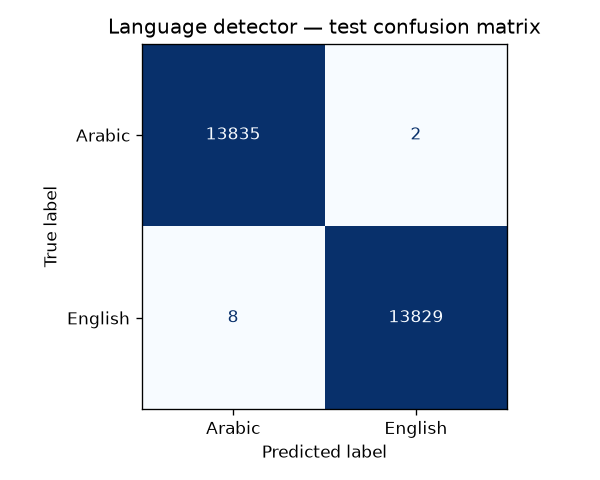

In [7]:
from IPython.display import display
cm = confusion_matrix(test_df["language"], y_pred, labels=LANG_LABELS)
print("Confusion matrix labels", LANG_LABELS)
print(cm)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=LANG_LABELS).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Language detector — test confusion matrix")
fig.tight_layout()
display(fig)

unseen = test_df[~test_df["clean_text"].isin(set(train_df["clean_text"]))]
unseen_pred = language_pipeline.predict(unseen["clean_text"])
print("\nUnseen-normalized test n=", len(unseen), unseen["language"].value_counts().to_dict())
print(classification_report(unseen["language"], unseen_pred, labels=LANG_LABELS, digits=4))
print(pd.Series(scores(unseen["language"], unseen_pred), name="unseen-normalized"))

Held-out test confusion matrix (`Arabic`, `English`). Source-id overlap **0**. Normalized-text overlap **3321** unique strings (short derived phrases that recur across different sources). Those overlapping test rows are **not** deleted.

|  | Pred Arabic | Pred English |
| :--- | ---: | ---: |
| **True Arabic** | 13835 | 2 |
| **True English** | 8 | 13829 |

Full test: accuracy / macro-F1 **0.9996** (n=27674).

Unseen-normalized subset (normalized form absent from train): **19292** rows (Arabic 10447, English 8845), accuracy / macro-F1 **0.9999**. Duplicate source reviews merged before splitting: **625**.

## 11. Best Model

In [8]:
print(language_pipeline)
print("test F1", scores(test_df["language"], y_pred)["F1"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char', max_features=40000,
                                 ngram_range=(2, 5))),
                ('clf', LinearSVC(max_iter=2000))])


test F1 0.9996386499794007


## 12. Save Model

In [9]:
clf = LanguageClassifier(language_pipeline)
path = clf.save(ROOT / "models" / "Language_classifier_weights.pkl")
print("saved", path.resolve())

saved /home/abdlrhman/Courses/IEEE SSCS/NLP/Week1/Project1/models/Language_classifier_weights.pkl


## 13. Example Predictions

Wrapper and `pipeline.predict` must match. The sklearn Pipeline is the detector.

In [10]:
model = LanguageClassifier.load(path)
cases = [
    "hello", "hi", "ok", "good", "service", "product",
    "This movie was amazing", "The service was terrible",
    "مرحبا", "اهلا", "شكرا", "جيد", "سيء", "فيلم", "خدمة", "منتج",
    "الفيلم جميل جدا", "الخدمة سيئة للغاية",
    "hello مرحبا", "iPhone ممتاز",
]
print(f"{'text':32} {'pipeline':8} wrapper")
for text in cases:
    cleaned = preprocess_language_detection(text)
    pipe = model.pipeline.predict([cleaned])[0]
    wrap = model.predict(text)
    print(f"{text:32} {pipe:8} {wrap}")
    assert pipe == wrap

text                             pipeline wrapper
hello                            English  English
hi                               English  English
ok                               English  English
good                             English  English
service                          English  English
product                          English  English
This movie was amazing           English  English
The service was terrible         English  English
مرحبا                            Arabic   Arabic
اهلا                             Arabic   Arabic
شكرا                             Arabic   Arabic
جيد                              Arabic   Arabic
سيء                              Arabic   Arabic
فيلم                             Arabic   Arabic
خدمة                             Arabic   Arabic
منتج                             Arabic   Arabic
الفيلم جميل جدا                  Arabic   Arabic
الخدمة سيئة للغاية               Arabic   Arabic
hello مرحبا                      English  English
iPhone ممت

## Integration check

In [11]:
from src.pipeline import NeurovaNLPPipeline
from src.validation import EmptyAfterPreprocessError, EmptyTextError, NonLinguisticTextError

nlp = NeurovaNLPPipeline.load()
for text in (
    "I absolutely loved this movie.",
    "This was one of the worst movies I've ever watched.",
    "الخدمة ممتازة والتجربة كانت رائعة",
    "الخدمة سيئة جدا ولن أكرر التجربة",
):
    print(nlp.analyze(text))

for bad, expected in (
    ("", EmptyTextError),
    ("   ", EmptyTextError),
    ("12345", NonLinguisticTextError),
    ("!!!", NonLinguisticTextError),
    ("🎉🎉🎉", NonLinguisticTextError),
    ("https://example.com", EmptyAfterPreprocessError),
    ("<br>", EmptyAfterPreprocessError),
    ("؟؟؟", NonLinguisticTextError),
    ("١٢٣", NonLinguisticTextError),
    ("َُِ", NonLinguisticTextError),
):
    try:
        nlp.analyze(bad)
        print("UNEXPECTED", repr(bad))
    except expected as exc:
        print(repr(bad), "->", type(exc).__name__, str(exc))

{'User Text': 'I absolutely loved this movie.', 'Language': 'English', 'Sentiment Classification': 'Positive'}
{'User Text': "This was one of the worst movies I've ever watched.", 'Language': 'English', 'Sentiment Classification': 'Negative'}
{'User Text': 'الخدمة ممتازة والتجربة كانت رائعة', 'Language': 'Arabic', 'Sentiment Classification': 'Positive'}
{'User Text': 'الخدمة سيئة جدا ولن أكرر التجربة', 'Language': 'Arabic', 'Sentiment Classification': 'Negative'}
'' -> EmptyTextError Text cannot be empty.
'   ' -> EmptyTextError Text cannot be empty.
'12345' -> NonLinguisticTextError Please enter meaningful Arabic or English text.
'!!!' -> NonLinguisticTextError Please enter meaningful Arabic or English text.
'🎉🎉🎉' -> NonLinguisticTextError Please enter meaningful Arabic or English text.
'https://example.com' -> EmptyAfterPreprocessError Please enter meaningful Arabic or English text.
'<br>' -> EmptyAfterPreprocessError Please enter meaningful Arabic or English text.
'؟؟؟' -> NonLingui